Implemented a **3-layer deep neural network for non-linear regression using only NumPy**:

* Generates **synthetic data** using a **3-variable non-linear function**.
* Implements a **fully connected neural network with ReLU activation**.
* Uses **manual backpropagation** with the **chain rule** for training.
* Trains using **gradient descent** and visualizes the **loss over epochs**.
* Includes **4D visualization** of the dataset.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

#  Generating Synthetic Data

In [ ]:
# Generate synthetic data using a 3-variable non-linear equation
def generate_data(num_samples=1000):
    x1 = np.random.uniform(-5, 5, num_samples)
    x2 = np.random.uniform(-5, 5, num_samples)
    x3 = np.random.uniform(-5, 5, num_samples)

    y = np.sin(x1) + np.cos(x2) + 0.5 * x3**2  # Non-linear function
    y = (y - np.min(y)) / (np.max(y) - np.min(y))  # Normalize target

    X = np.vstack([x1, x2, x3]).T
    return X, y

# Visualizing Data in 4D

In [ ]:
# Plot the generated data
def plot_4d(X, y):
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    sc = ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=y, cmap='viridis')
    plt.colorbar(sc)
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('X3')
    plt.title('4D Data Visualization')
    plt.show()

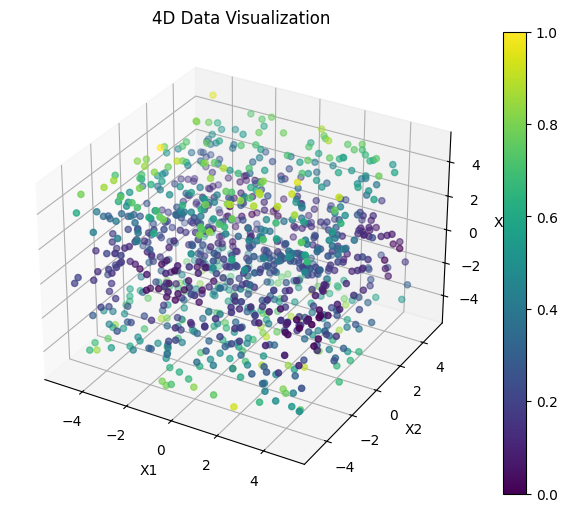

In [ ]:
# Generate data
X, y = generate_data(num_samples=1000)

# Call the function to visualize the 4D plot
plot_4d(X, y)

In [ ]:
import plotly.express as px
import pandas as pd

df = pd.DataFrame(X, columns=['X1', 'X2', 'X3'])
df['y'] = y  # Add target variable

fig = px.scatter_3d(df, x='X1', y='X2', z='X3', color='y', title="4D Data Visualization")
fig.show()


# Defining the Neural Network

The neural network follows this architecture:

**Input Layer → Hidden Layer 1 (10 neurons) → Hidden Layer 2 (10 neurons) → Output Layer (1 neuron)**

* The weights and biases are initialized randomly.
* The ReLU activation function is applied in hidden layers.
* The output layer has no activation function (linear output).

**Activation Function**

We use ReLU (Rectified Linear Unit), which is defined as:

            ReLU(x)=max(0,x)

Its derivative (used in backpropagation) is:

            ReLU’(x)={ 1, x>0
                       0, x≤0

In [ ]:
# Define activation functions and their derivatives
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

# Initializing Network Parameters

In [ ]:
# Initialize network parameters
input_dim = 3
hidden_dim1 = 10
hidden_dim2 = 10
output_dim = 1
learning_rate = 0.01
num_epochs = 1000

In [ ]:
np.random.seed(42)
W1 = np.random.randn(input_dim, hidden_dim1) * 0.01
b1 = np.zeros((1, hidden_dim1))
W2 = np.random.randn(hidden_dim1, hidden_dim2) * 0.01
b2 = np.zeros((1, hidden_dim2))
W3 = np.random.randn(hidden_dim2, output_dim) * 0.01
b3 = np.zeros((1, output_dim))

# Forward Propagation
For each training iteration, performed forward propagation:

* Compute activations for Hidden Layer 1:

    𝑍
    1
    =
    𝑋
    𝑊
    1
    +
    𝑏
    1
    
    𝐴
    1
    =
    ReLU
    (
    𝑍
    1
    )

* Compute activations for Hidden Layer 2:

   𝑍
    2
    =
    𝐴
    1
    𝑊
    2
    +
    𝑏
    2

    𝐴
    2
    =
    ReLU
    (
    𝑍
    2
    )

* Compute Output Layer:

    𝑍
    3
    =
    𝐴
    2
    𝑊
    3
    +
    𝑏
    3

    y pred = Z3 (No activation, since it's regression)


# Loss Function

  Mean Squared Error (MSE):

  Loss
      =
      1/
      𝑛
      ∑
      (
      𝑦
      pred
      −
      𝑦
      )
      *2

# Back Propogation

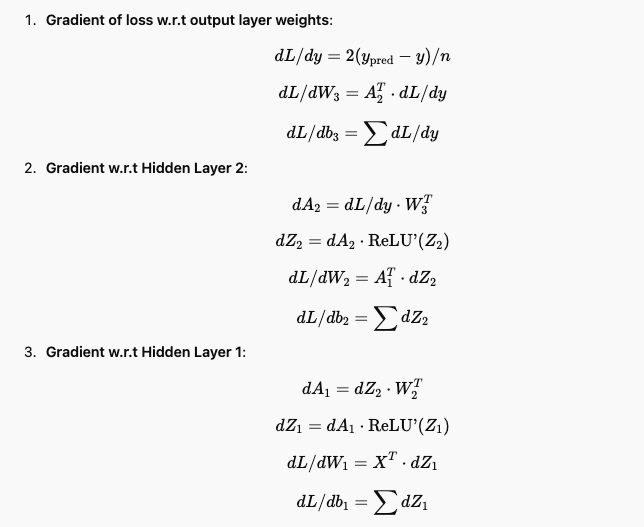

# Parameter Updates
Updated the weights and biases using gradient descent:

𝑊
𝑖
=
𝑊
𝑖
−
𝛼
⋅
𝑑
𝐿
/
𝑑
𝑊
𝑖

𝑏
𝑖
=
𝑏
𝑖
−
𝛼
⋅
𝑑
𝐿
/
𝑑
𝑏
𝑖


In [ ]:
# Training loop
X, y = generate_data()
y = y.reshape(-1, 1)
loss_history = []

for epoch in range(num_epochs):
    # Forward pass
    Z1 = X @ W1 + b1
    A1 = relu(Z1)
    Z2 = A1 @ W2 + b2
    A2 = relu(Z2)
    Z3 = A2 @ W3 + b3
    y_pred = Z3  # Linear output

    # Compute loss (MSE)
    loss = np.mean((y_pred - y) ** 2)
    loss_history.append(loss)

    # Backpropagation
    dL_dy = 2 * (y_pred - y) / y.shape[0]
    dL_dW3 = A2.T @ dL_dy
    dL_db3 = np.sum(dL_dy, axis=0, keepdims=True)

    dA2 = dL_dy @ W3.T
    dZ2 = dA2 * relu_derivative(Z2)
    dL_dW2 = A1.T @ dZ2
    dL_db2 = np.sum(dZ2, axis=0, keepdims=True)

    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * relu_derivative(Z1)
    dL_dW1 = X.T @ dZ1
    dL_db1 = np.sum(dZ1, axis=0, keepdims=True)

    # Update weights
    W3 -= learning_rate * dL_dW3
    b3 -= learning_rate * dL_db3
    W2 -= learning_rate * dL_dW2
    b2 -= learning_rate * dL_db2
    W1 -= learning_rate * dL_dW1
    b1 -= learning_rate * dL_db1

    if epoch % 100 == 0:
        print(f"Epoch {epoch}: Loss = {loss:.5f}")


Epoch 0: Loss = 0.21041
Epoch 100: Loss = 0.06750
Epoch 200: Loss = 0.06499
Epoch 300: Loss = 0.06495
Epoch 400: Loss = 0.06495
Epoch 500: Loss = 0.06495
Epoch 600: Loss = 0.06495
Epoch 700: Loss = 0.06495
Epoch 800: Loss = 0.06495
Epoch 900: Loss = 0.06495


# Training and Results


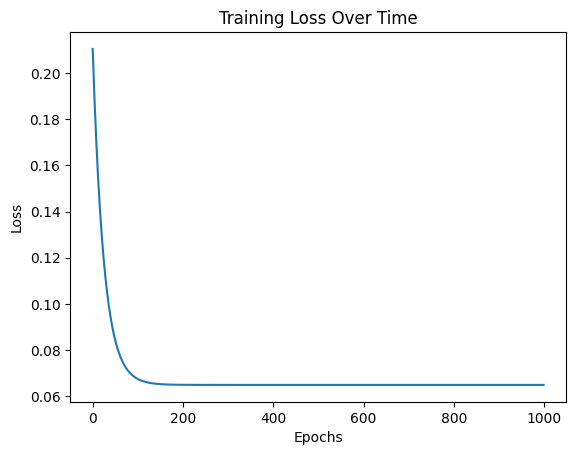

In [ ]:
# Plot training loss
plt.plot(loss_history)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss Over Time')
plt.show()

# Testing with New Data

In [ ]:
# Test on new data
X_test, y_test = generate_data(100)
y_test = y_test.reshape(-1, 1)
y_pred_test = X_test @ W1 + b1
print("Final Predictions:", y_pred_test[:5])

Final Predictions: [[-0.03658382  0.01223282 -0.01393241  0.03755808  0.03783458  0.00754561
   0.01643599 -0.02431844  0.03428034  0.01671429]
 [-0.01547409 -0.0136419  -0.00156455 -0.08784687 -0.05158056 -0.01366671
  -0.06048822  0.00056449 -0.02335446 -0.0522071 ]
 [-0.06484201 -0.01427379  0.02689496  0.04210151 -0.04944568 -0.03458836
   0.06230559  0.01940188 -0.01962967 -0.02260168]
 [ 0.05292732  0.00698285  0.01275005  0.07481603  0.03365696  0.01188793
   0.05824215  0.0192394   0.00062592  0.05146909]
 [-0.01226797  0.02652485 -0.0241291   0.07886139  0.0891115   0.02783312
   0.03239565 -0.03488348  0.05932182  0.0561718 ]]


# Summary
* ✅ 3-Layer NN implemented using NumPy
* ✅ Manual forward & backward propagation
* ✅ ReLU activation in hidden layers
* ✅ MSE loss function
* ✅ Gradient descent updates
* ✅ 4D visualization of data
* ✅ Final predictions on new data